<a href="https://colab.research.google.com/github/melekyakin/forklift-tracking-app/blob/main/Supply_Chain_Analysis_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data Loading

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# ── Global Aesthetics ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#FFFFFF',
    'axes.edgecolor':    '#CCCCCC',
    'axes.grid':         False,
    'grid.color':        '#EEEEEE',
    'grid.linewidth':    0.8,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.framealpha': 0.9,
})

# ── Palette Definitions ────────────────────────────────────────────────────────
PRODUCT_PALETTE  = {'haircare': '#FF6B6B', 'skincare': '#4ECDC4', 'cosmetics': '#FFE66D'}
CARRIER_PALETTE  = {'Carrier A': '#A78BFA', 'Carrier B': '#34D399', 'Carrier C': '#FB923C'}
LOCATION_PALETTE = {'Mumbai': '#60A5FA', 'Delhi': '#F472B6', 'Kolkata': '#FBBF24',
                    'Bangalore': '#34D399', 'Chennai': '#F87171'}
TRANSPORT_PALETTE= {'Road': '#93C5FD', 'Air': '#FCA5A5', 'Rail': '#86EFAC', 'Sea': '#FDE68A'}
SEQUENTIAL       = 'YlOrRd'
DIVERGING        = 'RdYlGn'

print('Libraries loaded successfully.')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Seaborn : {sns.__version__}')

Libraries loaded successfully.
Pandas  : 2.2.3
NumPy   : 2.1.3
Seaborn : 0.13.2


2. Data Loading

In [56]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "supply_chain_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "litonislam/supply-chain-data-analysis",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'supply-chain-data-analysis' dataset.


In [57]:
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 100 rows x 24 columns


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632



3. Data Overview

In [58]:
print('=' * 55)
print('  DATASET DIMENSIONS')
print('=' * 55)
print(f'  Rows    : {df.shape[0]}')
print(f'  Columns : {df.shape[1]}')

print('\n  COLUMN INVENTORY')
print('-' * 55)
summary = pd.DataFrame({
    'Dtype'      : df.dtypes,
    'Non-Null'   : df.notnull().sum(),
    'Null'       : df.isnull().sum(),
    'Unique'     : df.nunique(),
    'Sample'     : [str(df[c].iloc[0])[:30] for c in df.columns]
})
print(summary.to_string())

  DATASET DIMENSIONS
  Rows    : 100
  Columns : 24

  COLUMN INVENTORY
-------------------------------------------------------
                           Dtype  Non-Null  Null  Unique              Sample
Product type              object       100     0       3            haircare
SKU                       object       100     0     100                SKU0
Price                    float64       100     0     100   69.80800554211577
Availability               int64       100     0      63                  55
Number of products sold    int64       100     0      96                 802
Revenue generated        float64       100     0     100   8661.996792392383
Customer demographics     object       100     0       4          Non-binary
Stock levels               int64       100     0      65                  58
Lead times                 int64       100     0      29                   7
Order quantities           int64       100     0      61                  96
Shipping times           

4. Data Cleaning & Preprocessing

In [59]:
# ── Normalise column names ──────────────────────────────────────────────────────
df.columns = [c.strip() for c in df.columns]

# ── Confirm zero nulls ──────────────────────────────────────────────────────────
assert df.isnull().sum().sum() == 0, 'Unexpected nulls found!'
print('No null values detected. Dataset is complete.')

# ── Feature Engineering ─────────────────────────────────────────────────────────
df['Revenue per Unit']       = df['Revenue generated'] / df['Number of products sold'].replace(0, np.nan)
df['Profit Margin Proxy']    = (df['Revenue generated'] - df['Manufacturing costs'] - df['Shipping costs'] - df['Costs']) / df['Revenue generated']
df['Total Lead Time']        = df['Lead times'] + df['Manufacturing lead time']
df['Cost per Unit Shipped']  = df['Costs'] / df['Order quantities'].replace(0, np.nan)
df['Stock-to-Sales Ratio']   = df['Stock levels'] / df['Number of products sold'].replace(0, np.nan)
df['Production Efficiency']  = df['Number of products sold'] / df['Production volumes'].replace(0, np.nan)
df['Defect Flag']            = (df['Inspection results'] == 'Fail').astype(int)
df['High Revenue Flag']      = (df['Revenue generated'] > df['Revenue generated'].median()).astype(int)

print('\nEngineered Features Added:')
new_cols = ['Revenue per Unit', 'Profit Margin Proxy', 'Total Lead Time',
            'Cost per Unit Shipped', 'Stock-to-Sales Ratio', 'Production Efficiency',
            'Defect Flag', 'High Revenue Flag']
for col in new_cols:
    print(f'  + {col}')

print(f'\nFinal shape: {df.shape}')

No null values detected. Dataset is complete.

Engineered Features Added:
  + Revenue per Unit
  + Profit Margin Proxy
  + Total Lead Time
  + Cost per Unit Shipped
  + Stock-to-Sales Ratio
  + Production Efficiency
  + Defect Flag
  + High Revenue Flag

Final shape: (100, 32)


5. Univariate Analysis

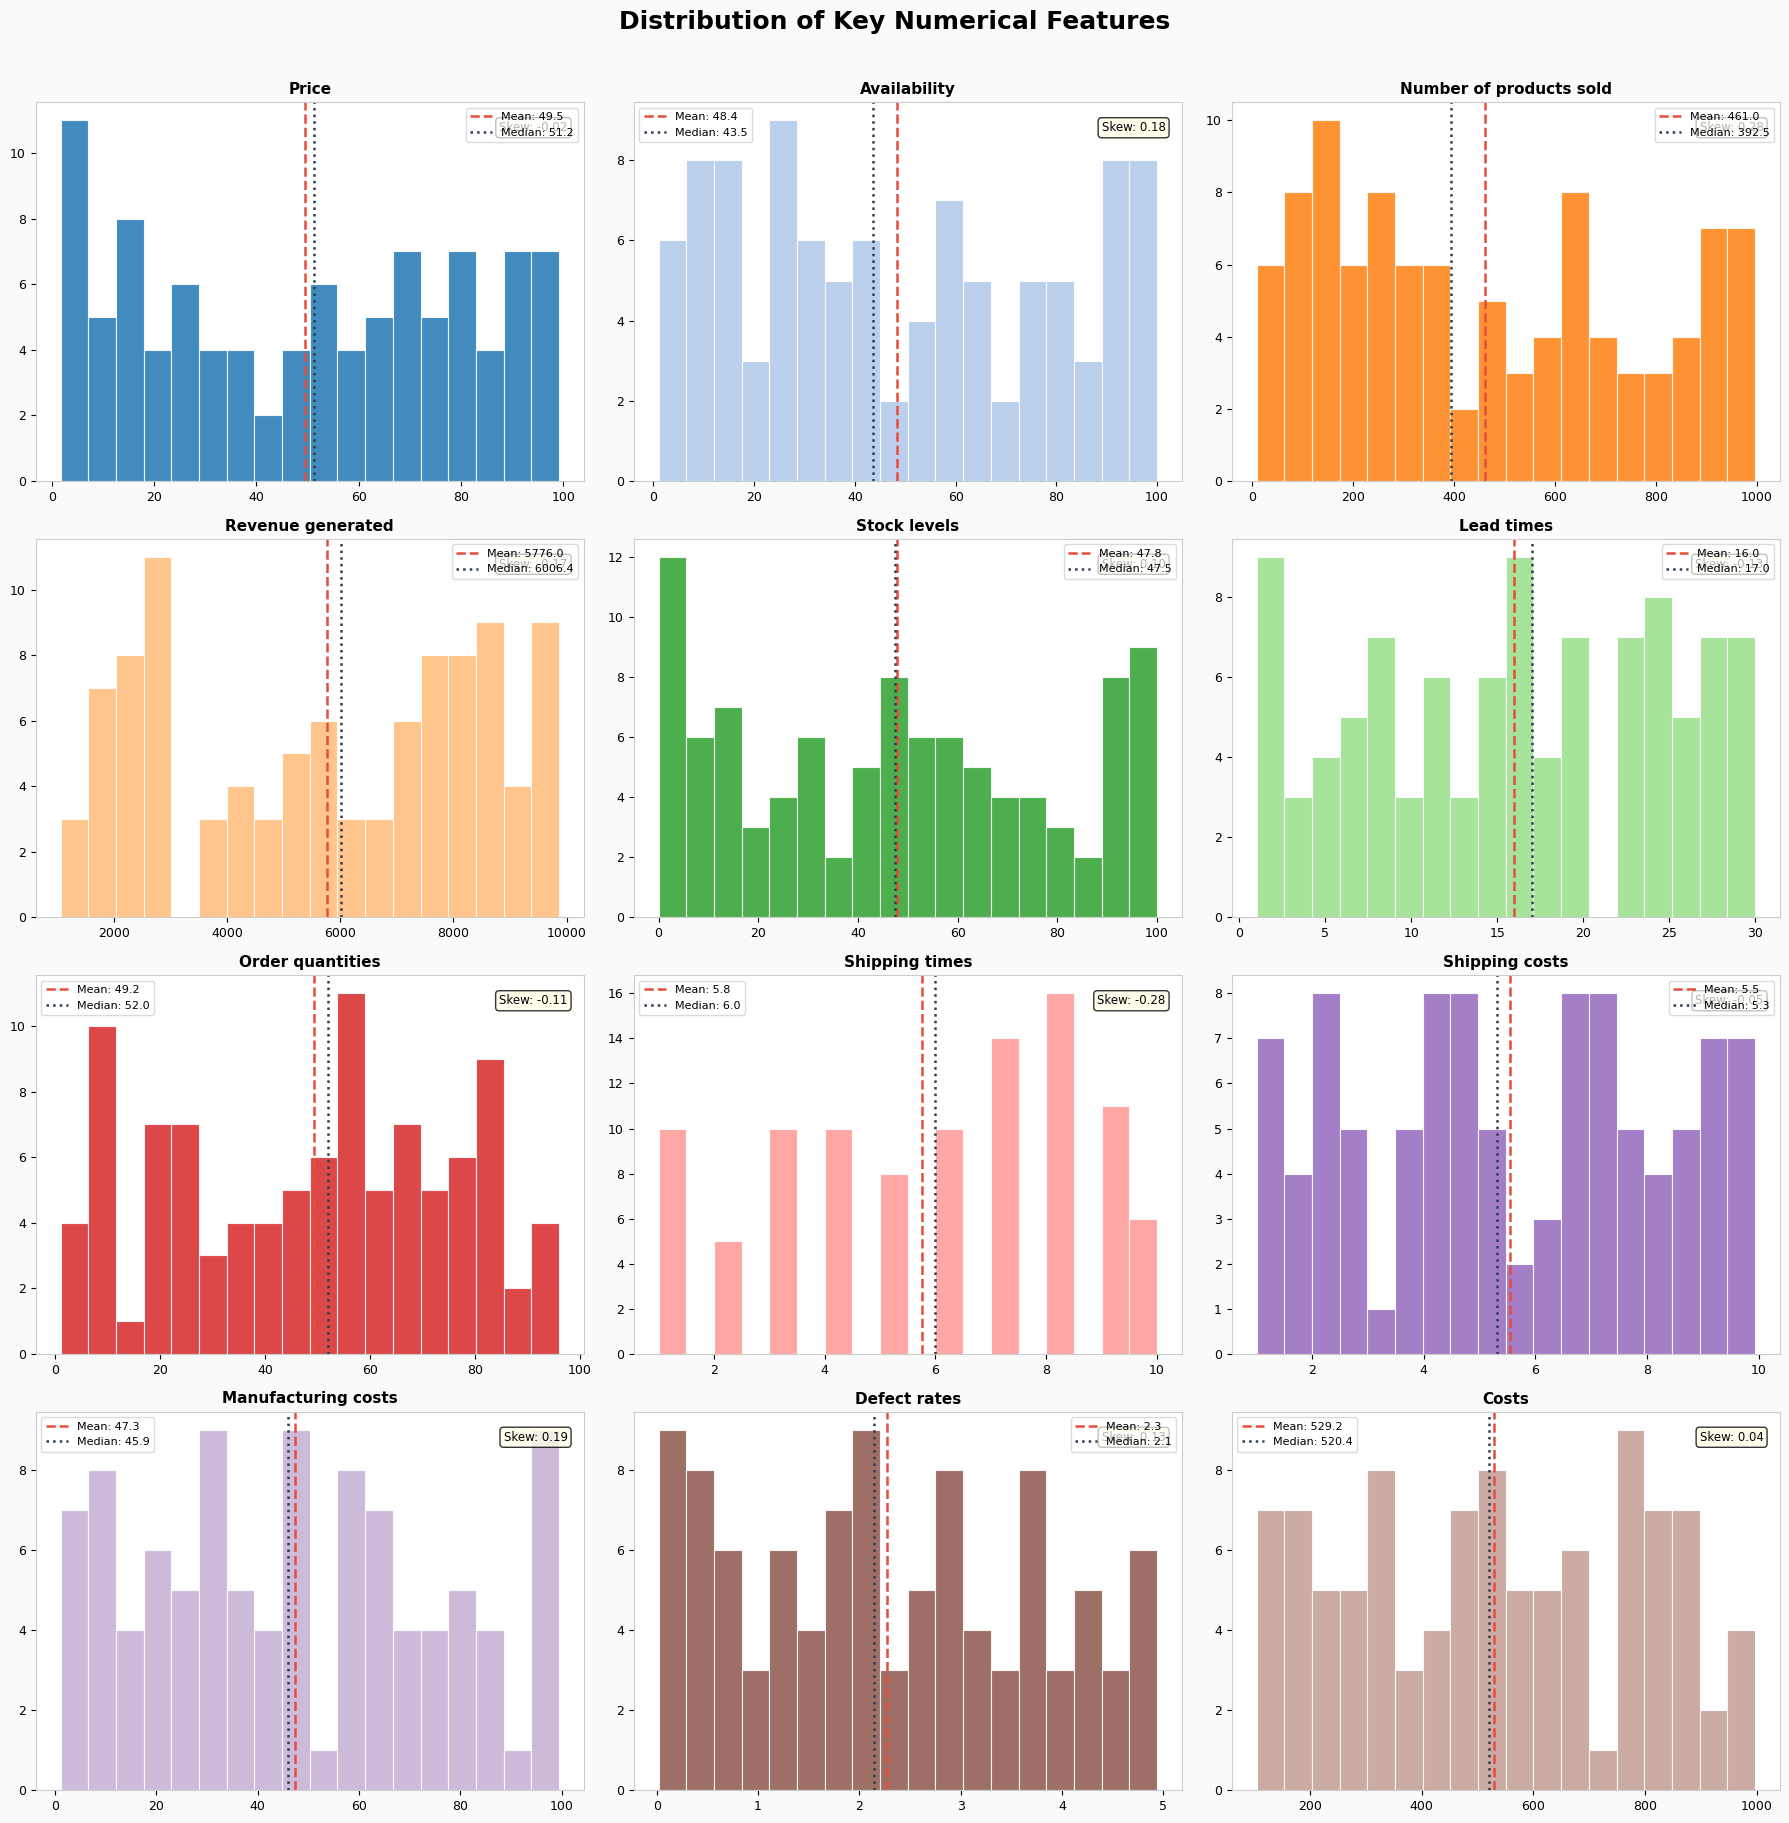

In [ ]:
num_cols = ['Price', 'Availability', 'Number of products sold', 'Revenue generated',
            'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
            'Shipping costs', 'Manufacturing costs', 'Defect rates', 'Costs']

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle('Distribution of Key Numerical Features', fontsize=18, fontweight='bold', y=1.01)

colors = plt.cm.tab20.colors

for i, (col, ax) in enumerate(zip(num_cols, axes.flatten())):
    data = df[col].dropna()
    ax.hist(data, bins=18, color=colors[i], edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.axvline(data.mean(),   color='#E74C3C', linewidth=1.8, linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='#2C3E50', linewidth=1.8, linestyle=':',  label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    skew = data.skew()
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFDE7', alpha=0.8))
    ax.legend(fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig('01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

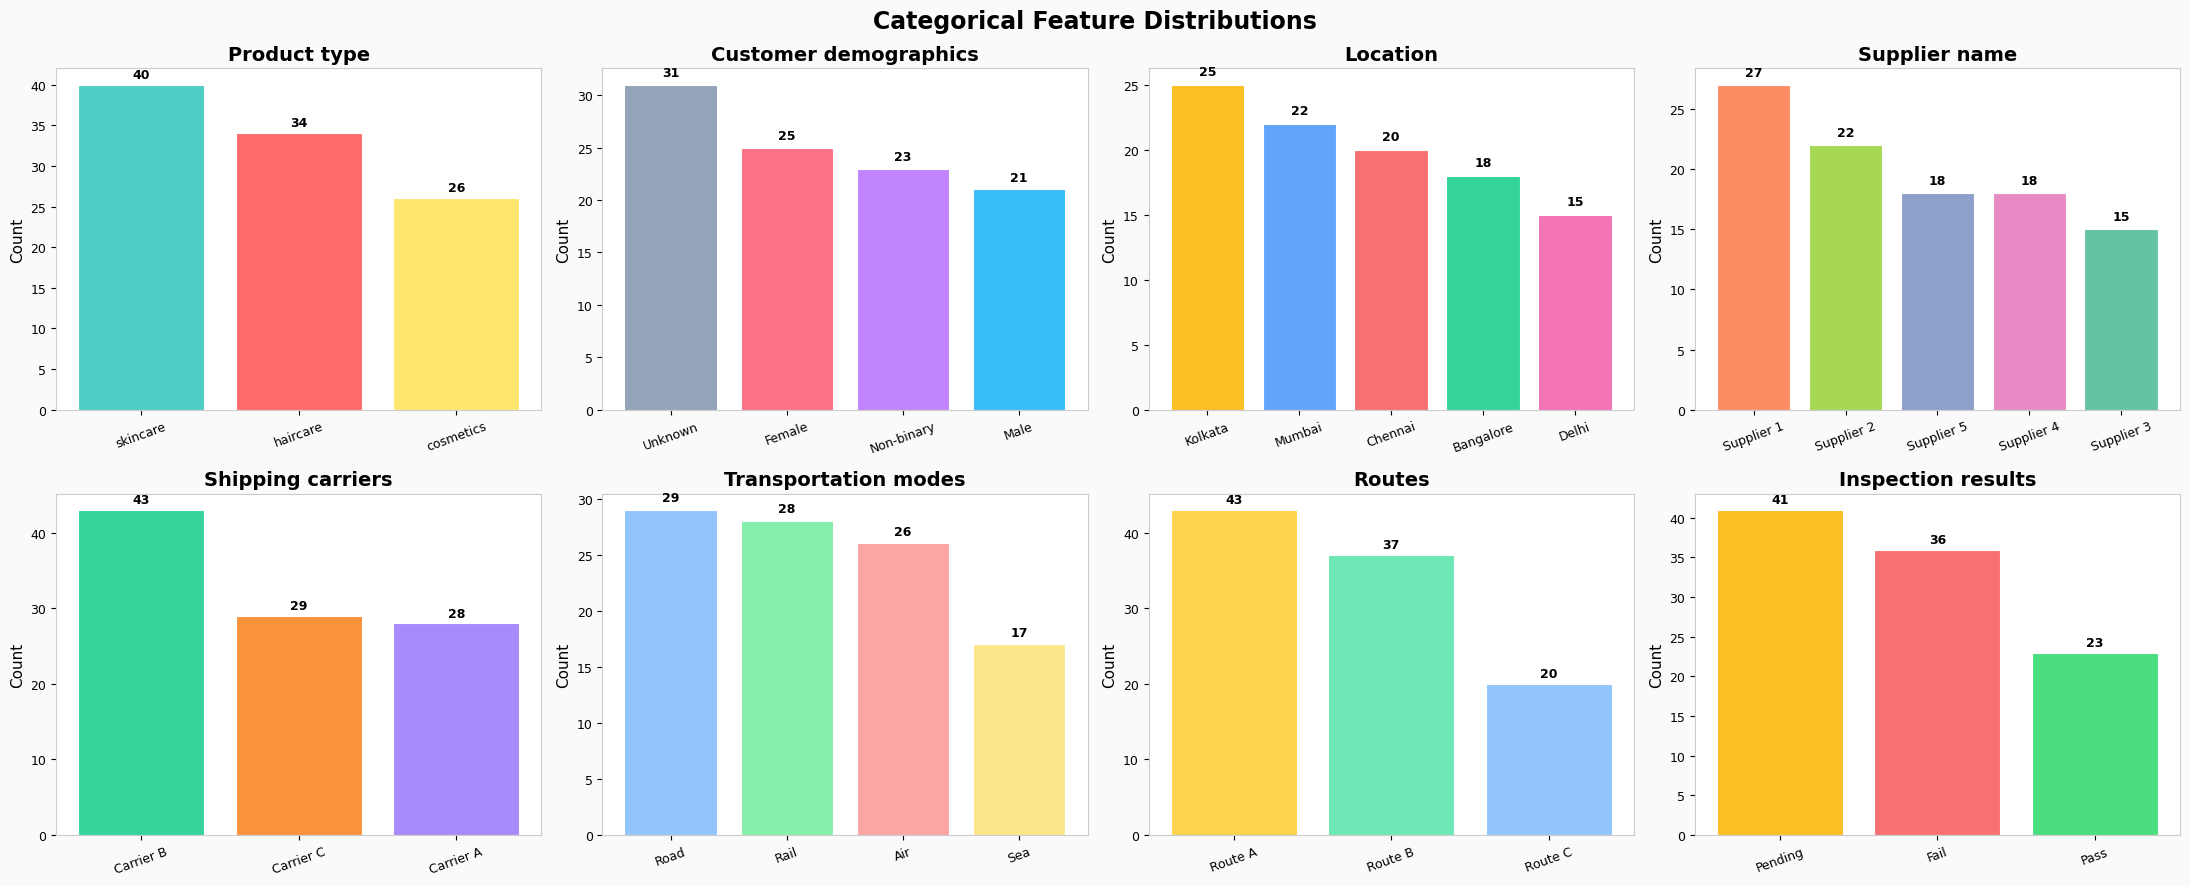

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Categorical Feature Distributions', fontsize=17, fontweight='bold')

cat_plot_cols = [
    ('Product type',       PRODUCT_PALETTE),
    ('Customer demographics', {'Non-binary': '#C084FC', 'Female': '#FB7185', 'Male': '#38BDF8', 'Unknown': '#94A3B8'}),
    ('Location',           LOCATION_PALETTE),
    ('Supplier name',      dict(zip(df['Supplier name'].unique(), plt.cm.Set2.colors))),
    ('Shipping carriers',  CARRIER_PALETTE),
    ('Transportation modes', TRANSPORT_PALETTE),
    ('Routes',             {'Route A': '#FCD34D', 'Route B': '#6EE7B7', 'Route C': '#93C5FD'}),
    ('Inspection results', {'Pass': '#4ADE80', 'Fail': '#F87171', 'Pending': '#FBBF24'}),
]

for ax, (col, palette) in zip(axes.flatten(), cat_plot_cols):
    vc = df[col].value_counts()
    bar_colors = [palette.get(k, '#CCCCCC') for k in vc.index]
    bars = ax.bar(vc.index, vc.values, color=bar_colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('02_categoricals.png', dpi=150, bbox_inches='tight')
plt.show()

6. Bivariate & Correlation Analysis

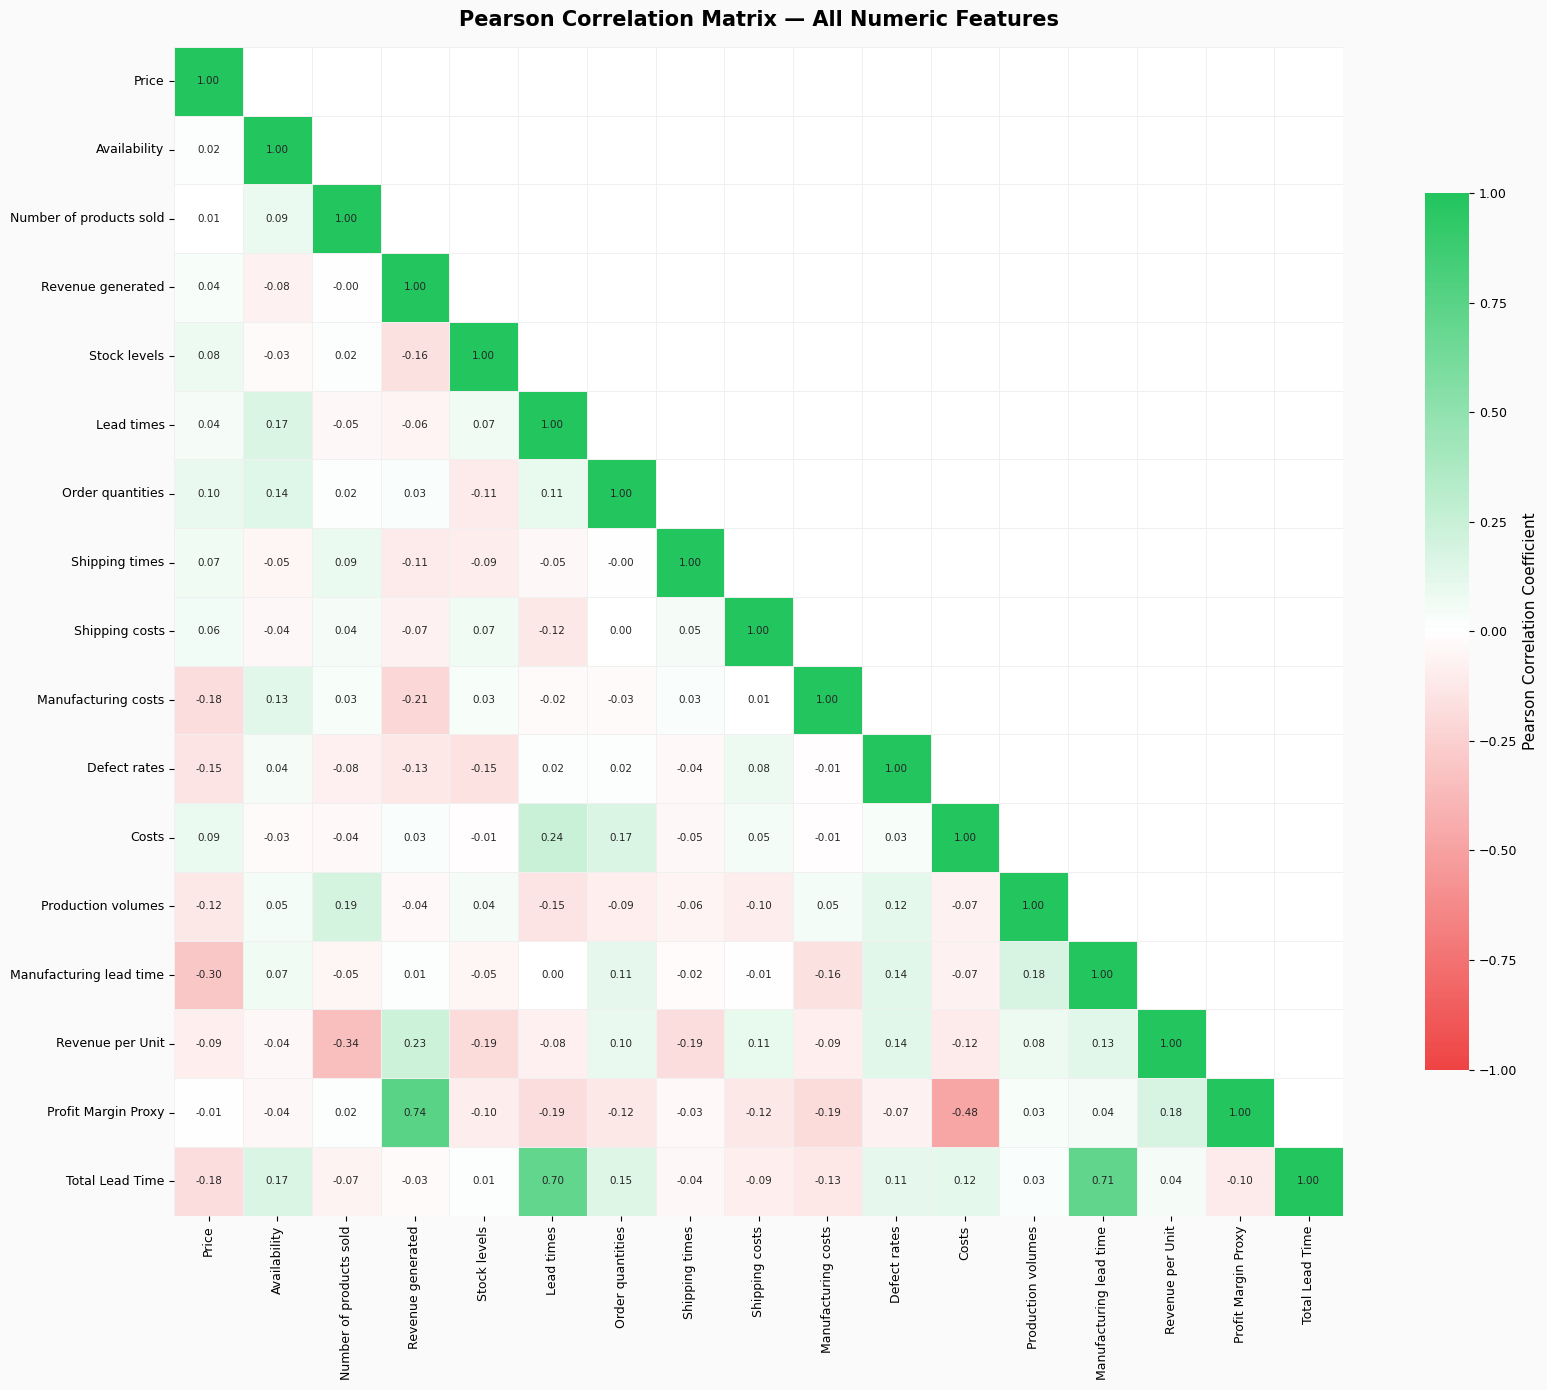

In [ ]:
num_features = ['Price', 'Availability', 'Number of products sold', 'Revenue generated',
                'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
                'Shipping costs', 'Manufacturing costs', 'Defect rates', 'Costs',
                'Production volumes', 'Manufacturing lead time',
                'Revenue per Unit', 'Profit Margin Proxy', 'Total Lead Time']

corr_matrix = df[num_features].corr()

# Generate mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(18, 14))
cmap = LinearSegmentedColormap.from_list('rg', ['#EF4444', '#FFFFFF', '#22C55E'])

sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7.5},
    linewidths=0.5, linecolor='#F0F0F0',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson Correlation Coefficient'}
)

ax.set_title('Pearson Correlation Matrix — All Numeric Features', fontsize=15, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Extract and rank all correlation pairs
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'Correlation']
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Abs Correlation', ascending=False)

print('TOP 15 STRONGEST CORRELATIONS')
print('=' * 65)
print(corr_pairs.head(15)[['Feature A', 'Feature B', 'Correlation']].to_string(index=False))

print('\nTOP 5 NEGATIVE CORRELATIONS')
print('=' * 65)
print(corr_pairs[corr_pairs['Correlation'] < 0].head(5)[['Feature A', 'Feature B', 'Correlation']].to_string(index=False))

TOP 15 STRONGEST CORRELATIONS
              Feature A               Feature B  Correlation
    Profit Margin Proxy       Revenue generated     0.742795
        Total Lead Time Manufacturing lead time     0.713311
        Total Lead Time              Lead times     0.703244
    Profit Margin Proxy                   Costs    -0.478381
       Revenue per Unit Number of products sold    -0.344795
Manufacturing lead time                   Price    -0.301313
                  Costs              Lead times     0.243686
       Revenue per Unit       Revenue generated     0.232143
    Manufacturing costs       Revenue generated    -0.214025
    Profit Margin Proxy     Manufacturing costs    -0.191368
       Revenue per Unit            Stock levels    -0.190515
     Production volumes Number of products sold     0.187945
    Profit Margin Proxy              Lead times    -0.187172
       Revenue per Unit          Shipping times    -0.185224
Manufacturing lead time      Production volumes     0.1

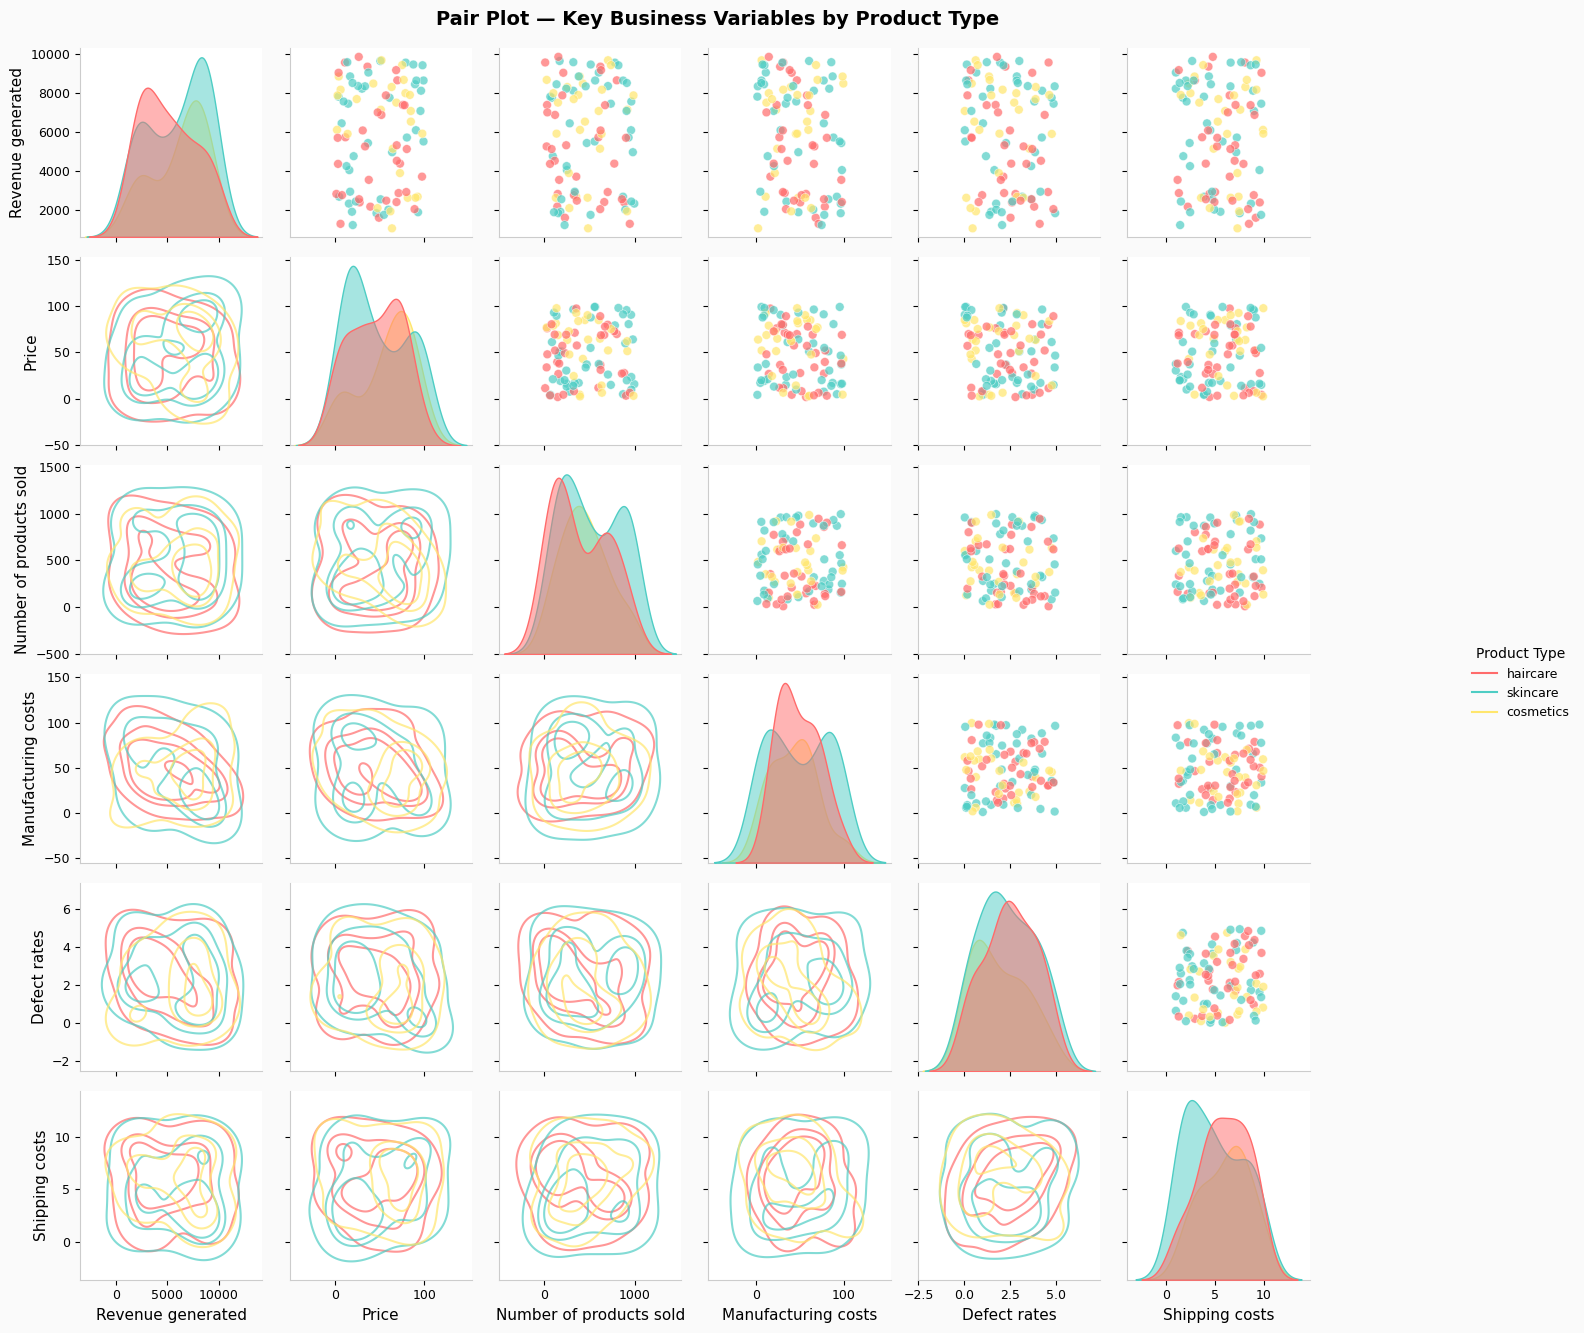

In [ ]:
key_vars = ['Revenue generated', 'Price', 'Number of products sold',
            'Manufacturing costs', 'Defect rates', 'Shipping costs']

pair_df = df[key_vars + ['Product type']].copy()

g = sns.PairGrid(pair_df, hue='Product type', palette=PRODUCT_PALETTE,
                 diag_sharey=False, height=2.2)
g.map_upper(sns.scatterplot, alpha=0.7, s=40, edgecolor='white', linewidth=0.4)
g.map_diag(sns.kdeplot, fill=True, alpha=0.5)
g.map_lower(sns.kdeplot, levels=4, alpha=0.7)
g.add_legend(title='Product Type', bbox_to_anchor=(1.02, 0.5), loc='center left')
g.figure.suptitle('Pair Plot — Key Business Variables by Product Type', y=1.01, fontsize=14, fontweight='bold')

plt.savefig('04_pairplot.png', dpi=130, bbox_inches='tight')
plt.show()


7. Product & Revenue Intelligence

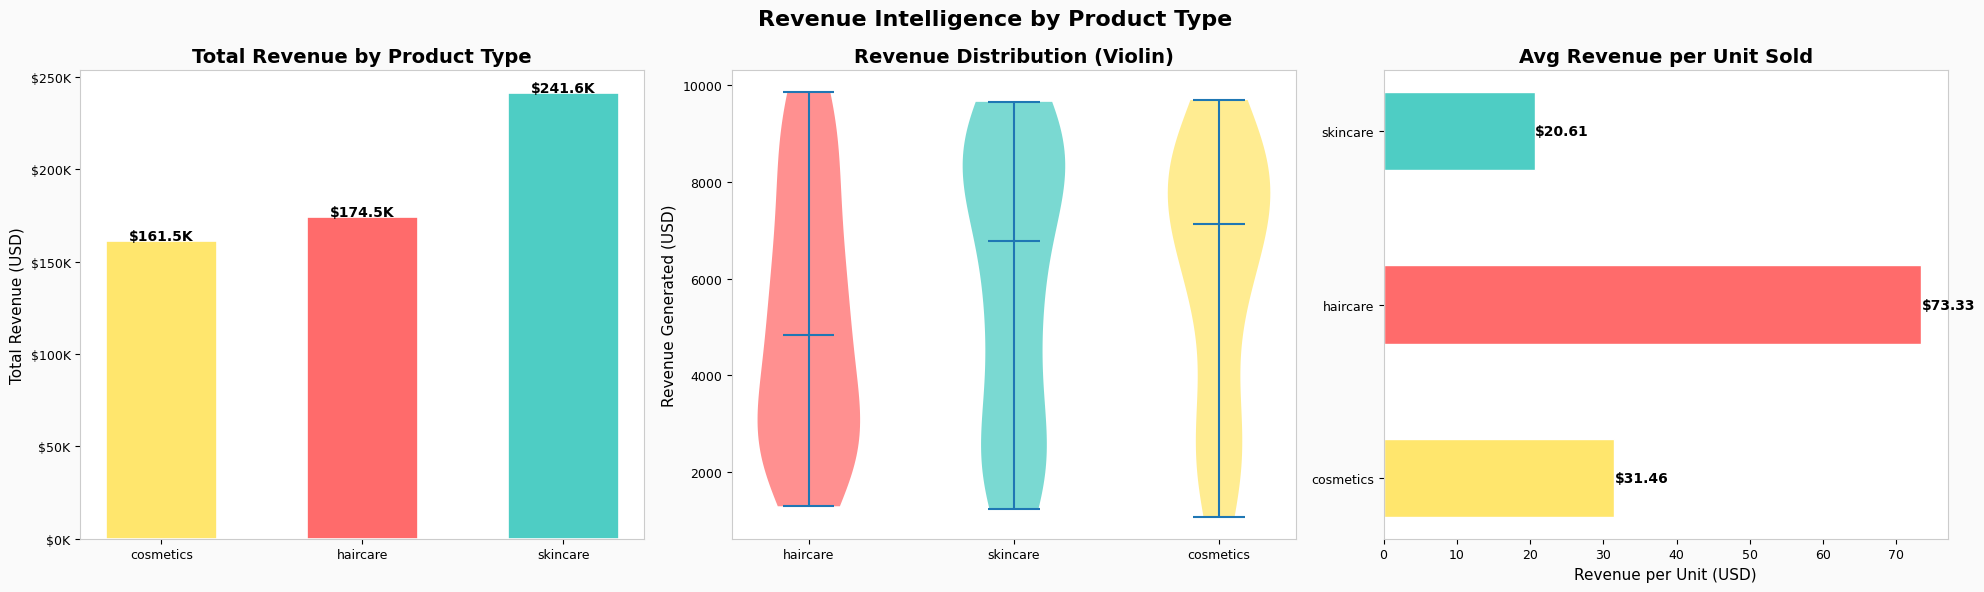

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Revenue Intelligence by Product Type', fontsize=16, fontweight='bold')

prod_rev = df.groupby('Product type')['Revenue generated'].agg(['sum', 'mean', 'count'])

# 1. Total Revenue
ax = axes[0]
bars = ax.bar(prod_rev.index, prod_rev['sum'],
              color=[PRODUCT_PALETTE[p] for p in prod_rev.index],
              edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, prod_rev['sum']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${val/1000:.1f}K', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Total Revenue by Product Type')
ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# 2. Revenue Distribution — Violin
ax = axes[1]
parts = ax.violinplot(
    [df[df['Product type']==p]['Revenue generated'].values for p in df['Product type'].unique()],
    positions=range(len(df['Product type'].unique())),
    showmedians=True, showmeans=False
)
for i, (pc, ptype) in enumerate(zip(parts['bodies'], df['Product type'].unique())):
    pc.set_facecolor(PRODUCT_PALETTE[ptype])
    pc.set_alpha(0.75)
ax.set_xticks(range(len(df['Product type'].unique())))
ax.set_xticklabels(df['Product type'].unique())
ax.set_title('Revenue Distribution (Violin)')
ax.set_ylabel('Revenue Generated (USD)')

# 3. Revenue per Unit
ax = axes[2]
prod_rpu = df.groupby('Product type')['Revenue per Unit'].mean()
bars = ax.barh(prod_rpu.index, prod_rpu.values,
               color=[PRODUCT_PALETTE[p] for p in prod_rpu.index],
               edgecolor='white', height=0.45)
for bar, val in zip(bars, prod_rpu.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Avg Revenue per Unit Sold')
ax.set_xlabel('Revenue per Unit (USD)')

plt.tight_layout()
plt.savefig('05_revenue_product.png', dpi=150, bbox_inches='tight')
plt.show()

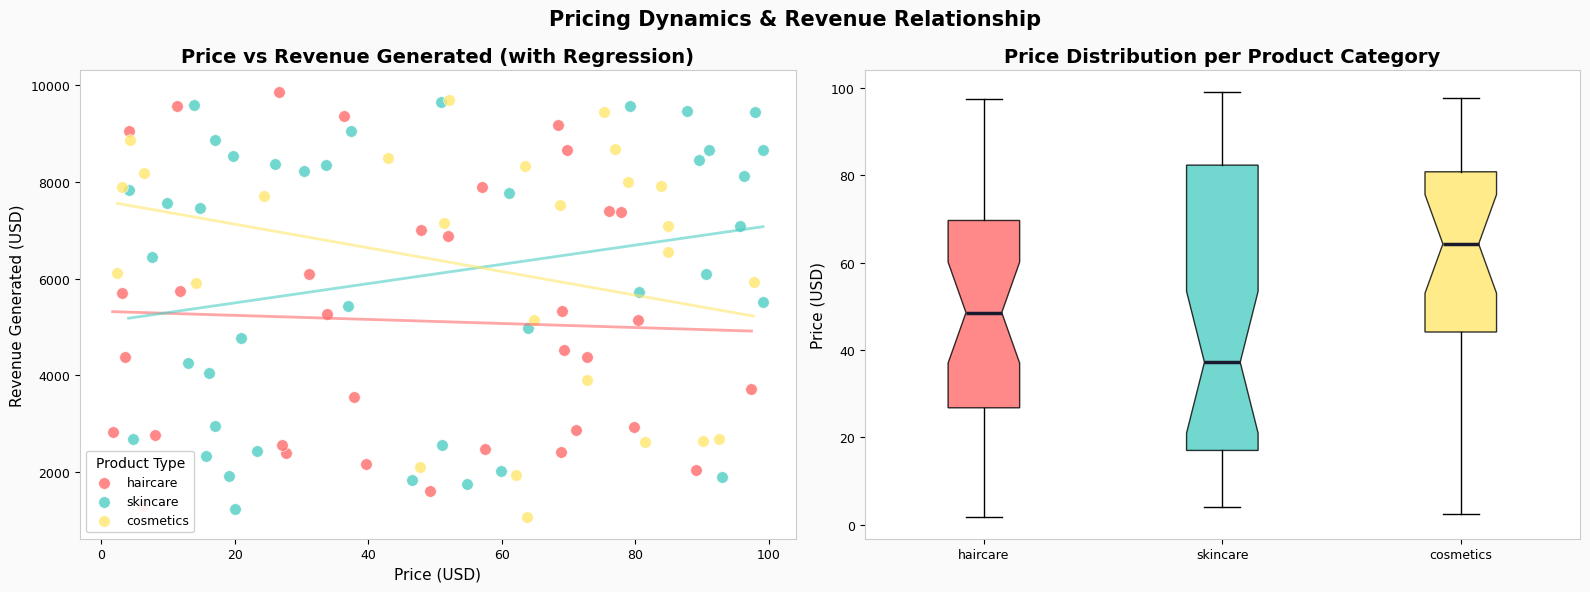

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pricing Dynamics & Revenue Relationship', fontsize=15, fontweight='bold')

# Scatter: Price vs Revenue
ax = axes[0]
for ptype in df['Product type'].unique():
    sub = df[df['Product type'] == ptype]
    ax.scatter(sub['Price'], sub['Revenue generated'],
               color=PRODUCT_PALETTE[ptype], s=70, alpha=0.8,
               edgecolors='white', linewidth=0.5, label=ptype)
    # Regression line
    m, b, r, p, _ = stats.linregress(sub['Price'], sub['Revenue generated'])
    x_range = np.linspace(sub['Price'].min(), sub['Price'].max(), 100)
    ax.plot(x_range, m*x_range + b, color=PRODUCT_PALETTE[ptype], linewidth=2, alpha=0.6)

ax.set_title('Price vs Revenue Generated (with Regression)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Revenue Generated (USD)')
ax.legend(title='Product Type')

# Price box per category
ax = axes[1]
data_by_type = [df[df['Product type']==p]['Price'].values for p in df['Product type'].unique()]
bp = ax.boxplot(data_by_type, patch_artist=True, notch=True,
                medianprops=dict(color='#1A1A2E', linewidth=2.5))
for patch, ptype in zip(bp['boxes'], df['Product type'].unique()):
    patch.set_facecolor(PRODUCT_PALETTE[ptype])
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(df['Product type'].unique())+1))
ax.set_xticklabels(df['Product type'].unique())
ax.set_title('Price Distribution per Product Category')
ax.set_ylabel('Price (USD)')

plt.tight_layout()
plt.savefig('06_pricing.png', dpi=150, bbox_inches='tight')
plt.show()

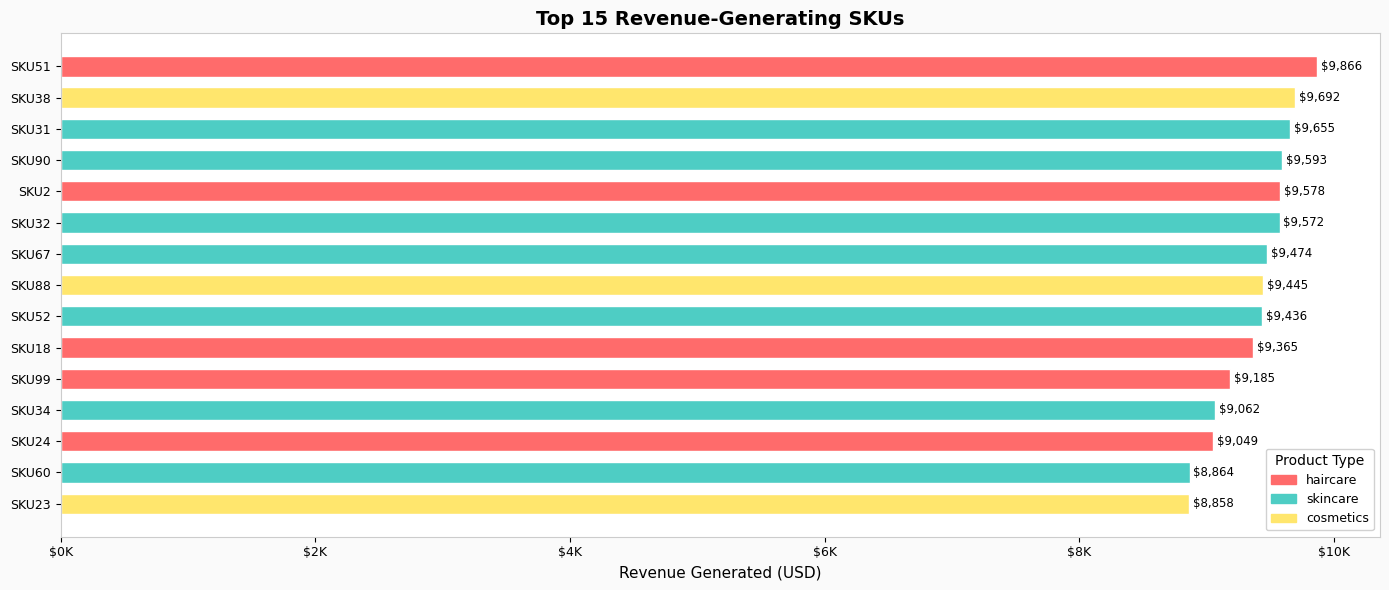

In [62]:
top_skus = df.nlargest(15, 'Revenue generated')[['SKU', 'Product type', 'Revenue generated', 'Price', 'Number of products sold']]

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = [PRODUCT_PALETTE[p] for p in top_skus['Product type']]
bars = ax.barh(top_skus['SKU'], top_skus['Revenue generated'],
               color=bar_colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, top_skus['Revenue generated']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=8.5)

ax.set_xlabel('Revenue Generated (USD)')
ax.set_title('Top 15 Revenue-Generating SKUs', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.invert_yaxis()

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in PRODUCT_PALETTE.items()]
ax.legend(handles=legend_patches, title='Product Type', loc='lower right')

plt.tight_layout()
plt.savefig('07_top_skus.png', dpi=150, bbox_inches='tight')
plt.show()

8. Logistics & Carrier Performance

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Logistics & Carrier Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Carrier vs Shipping Cost
ax = axes[0, 0]
carrier_cost = df.groupby('Shipping carriers')['Shipping costs'].describe()
bp = ax.boxplot(
    [df[df['Shipping carriers']==c]['Shipping costs'].values for c in df['Shipping carriers'].unique()],
    patch_artist=True, notch=False,
    medianprops=dict(color='#1A1A2E', linewidth=2)
)
for patch, carrier in zip(bp['boxes'], df['Shipping carriers'].unique()):
    patch.set_facecolor(CARRIER_PALETTE[carrier])
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(df['Shipping carriers'].unique())+1))
ax.set_xticklabels(df['Shipping carriers'].unique())
ax.set_title('Shipping Cost Distribution by Carrier')
ax.set_ylabel('Shipping Cost (USD)')

# 2. Shipping Times by Transportation Mode
ax = axes[0, 1]
for i, mode in enumerate(df['Transportation modes'].unique()):
    data = df[df['Transportation modes']==mode]['Shipping times']
    ax.scatter([i]*len(data), data, color=TRANSPORT_PALETTE[mode],
               alpha=0.6, s=50, edgecolors='white', linewidth=0.4)
    ax.hlines(data.mean(), i-0.3, i+0.3, color=TRANSPORT_PALETTE[mode],
              linewidth=3, alpha=1, label=f'{mode} (avg={data.mean():.1f})')
ax.set_xticks(range(len(df['Transportation modes'].unique())))
ax.set_xticklabels(df['Transportation modes'].unique())
ax.set_title('Shipping Times by Transportation Mode')
ax.set_ylabel('Shipping Time (days)')
ax.legend(fontsize=8)

# 3. Route vs Average Cost
ax = axes[1, 0]
route_cost = df.groupby('Routes')['Costs'].agg(['mean', 'std'])
route_colors = {'Route A': '#FCD34D', 'Route B': '#6EE7B7', 'Route C': '#93C5FD'}
bars = ax.bar(route_cost.index, route_cost['mean'],
              yerr=route_cost['std'], capsize=6,
              color=[route_colors[r] for r in route_cost.index],
              edgecolor='white', width=0.5,
              error_kw={'ecolor': '#555', 'linewidth': 1.5})
for bar, val in zip(bars, route_cost['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Average Logistics Cost by Route (with Std Dev)')
ax.set_ylabel('Average Cost (USD)')

# 4. Carrier Market Share Donut
ax = axes[1, 1]
carrier_counts = df['Shipping carriers'].value_counts()
wedge_colors = [CARRIER_PALETTE[c] for c in carrier_counts.index]
wedges, texts, autotexts = ax.pie(
    carrier_counts.values,
    labels=carrier_counts.index,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title('Carrier Market Share (SKU Count)')

plt.tight_layout()
plt.savefig('08_logistics.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Transportation Mode Comparative Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Transportation Mode: Cost, Defects & Revenue Impact', fontsize=15, fontweight='bold')

transport_summary = df.groupby('Transportation modes').agg(
    Avg_Shipping_Cost=('Shipping costs', 'mean'),
    Avg_Defect_Rate=('Defect rates', 'mean'),
    Avg_Revenue=('Revenue generated', 'mean'),
    Count=('SKU', 'count')
).reset_index()

for ax, (metric, label, fmt) in zip(axes, [
    ('Avg_Shipping_Cost', 'Avg Shipping Cost (USD)', '${x:.1f}'),
    ('Avg_Defect_Rate',   'Avg Defect Rate (%)',     '{x:.2f}%'),
    ('Avg_Revenue',       'Avg Revenue (USD)',       '${x:.0f}'),
]):
    bar_colors = [TRANSPORT_PALETTE[m] for m in transport_summary['Transportation modes']]
    bars = ax.bar(transport_summary['Transportation modes'], transport_summary[metric],
                  color=bar_colors, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, transport_summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(x=val), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig('09_transport_modes.png', dpi=150, bbox_inches='tight')
plt.show()

9. Supplier & Manufacturing Analysis

In [ ]:
supplier_agg = df.groupby('Supplier name').agg(
    SKU_Count           = ('SKU', 'count'),
    Avg_Manufacturing_Cost = ('Manufacturing costs', 'mean'),
    Avg_Defect_Rate     = ('Defect rates', 'mean'),
    Avg_Lead_Time       = ('Lead time', 'mean'),
    Avg_Production_Vol  = ('Production volumes', 'mean'),
    Avg_Mfg_Lead_Time   = ('Manufacturing lead time', 'mean'),
    Fail_Rate           = ('Defect Flag', 'mean'),
    Total_Revenue       = ('Revenue generated', 'sum')
).reset_index()

SUPPLIER_PALETTE = dict(zip(supplier_agg['Supplier name'],
                            ['#60A5FA', '#F472B6', '#34D399', '#FBBF24', '#A78BFA']))

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Supplier Performance Matrix', fontsize=16, fontweight='bold')

metrics = [
    ('Avg_Manufacturing_Cost', 'Avg Manufacturing Cost (USD)'),
    ('Avg_Defect_Rate',         'Avg Defect Rate (%)'),
    ('Avg_Lead_Time',           'Avg Lead Time (days)'),
    ('Avg_Production_Vol',      'Avg Production Volume (units)'),
    ('Avg_Mfg_Lead_Time',       'Avg Manufacturing Lead Time (days)'),
    ('Total_Revenue',           'Total Revenue Contributed (USD)'),
]

for ax, (metric, label) in zip(axes.flatten(), metrics):
    sorted_df = supplier_agg.sort_values(metric, ascending=(metric != 'Total_Revenue'))
    bar_c = [SUPPLIER_PALETTE[s] for s in sorted_df['Supplier name']]
    bars = ax.barh(sorted_df['Supplier name'], sorted_df[metric],
                   color=bar_c, edgecolor='white', height=0.55)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label)

plt.tight_layout()
plt.savefig('10_suppliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Supplier x Location crosstab
pivot = df.pivot_table(index='Supplier name', columns='Location', values='Revenue generated',
                        aggfunc='mean', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5,
            linecolor='#E0E0E0', ax=ax,
            cbar_kws={'label': 'Avg Revenue (USD)'})
ax.set_title('Average Revenue: Supplier x Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Supplier Name')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('11_supplier_location.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lead Time Analysis', fontsize=15, fontweight='bold')

# Lead times vs Revenue
ax = axes[0]
scatter = ax.scatter(df['Total Lead Time'], df['Revenue generated'],
                     c=df['Manufacturing costs'], cmap='YlOrRd',
                     s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Manufacturing Cost (USD)')
m, b, r, p, _ = stats.linregress(df['Total Lead Time'], df['Revenue generated'])
x_line = np.linspace(df['Total Lead Time'].min(), df['Total Lead Time'].max(), 100)
ax.plot(x_line, m*x_line+b, color='#E74C3C', linewidth=2, linestyle='--',
        label=f'r = {r:.3f}, p = {p:.3f}')
ax.set_title('Total Lead Time vs Revenue (coloured by Mfg Cost)')
ax.set_xlabel('Total Lead Time (days)')
ax.set_ylabel('Revenue Generated (USD)')
ax.legend()

# Lead time distribution by product
ax = axes[1]
for ptype in df['Product type'].unique():
    sub = df[df['Product type']==ptype]['Total Lead Time']
    ax.hist(sub, bins=12, alpha=0.6, color=PRODUCT_PALETTE[ptype], label=ptype, edgecolor='white')
ax.axvline(df['Total Lead Time'].mean(), color='#2C3E50', linestyle='--', linewidth=2,
           label=f'Overall Mean: {df["Total Lead Time"].mean():.1f} days')
ax.set_title('Total Lead Time Distribution by Product')
ax.set_xlabel('Total Lead Time (days)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('12_lead_times.png', dpi=150, bbox_inches='tight')
plt.show()

10. Quality Control Deep Dive

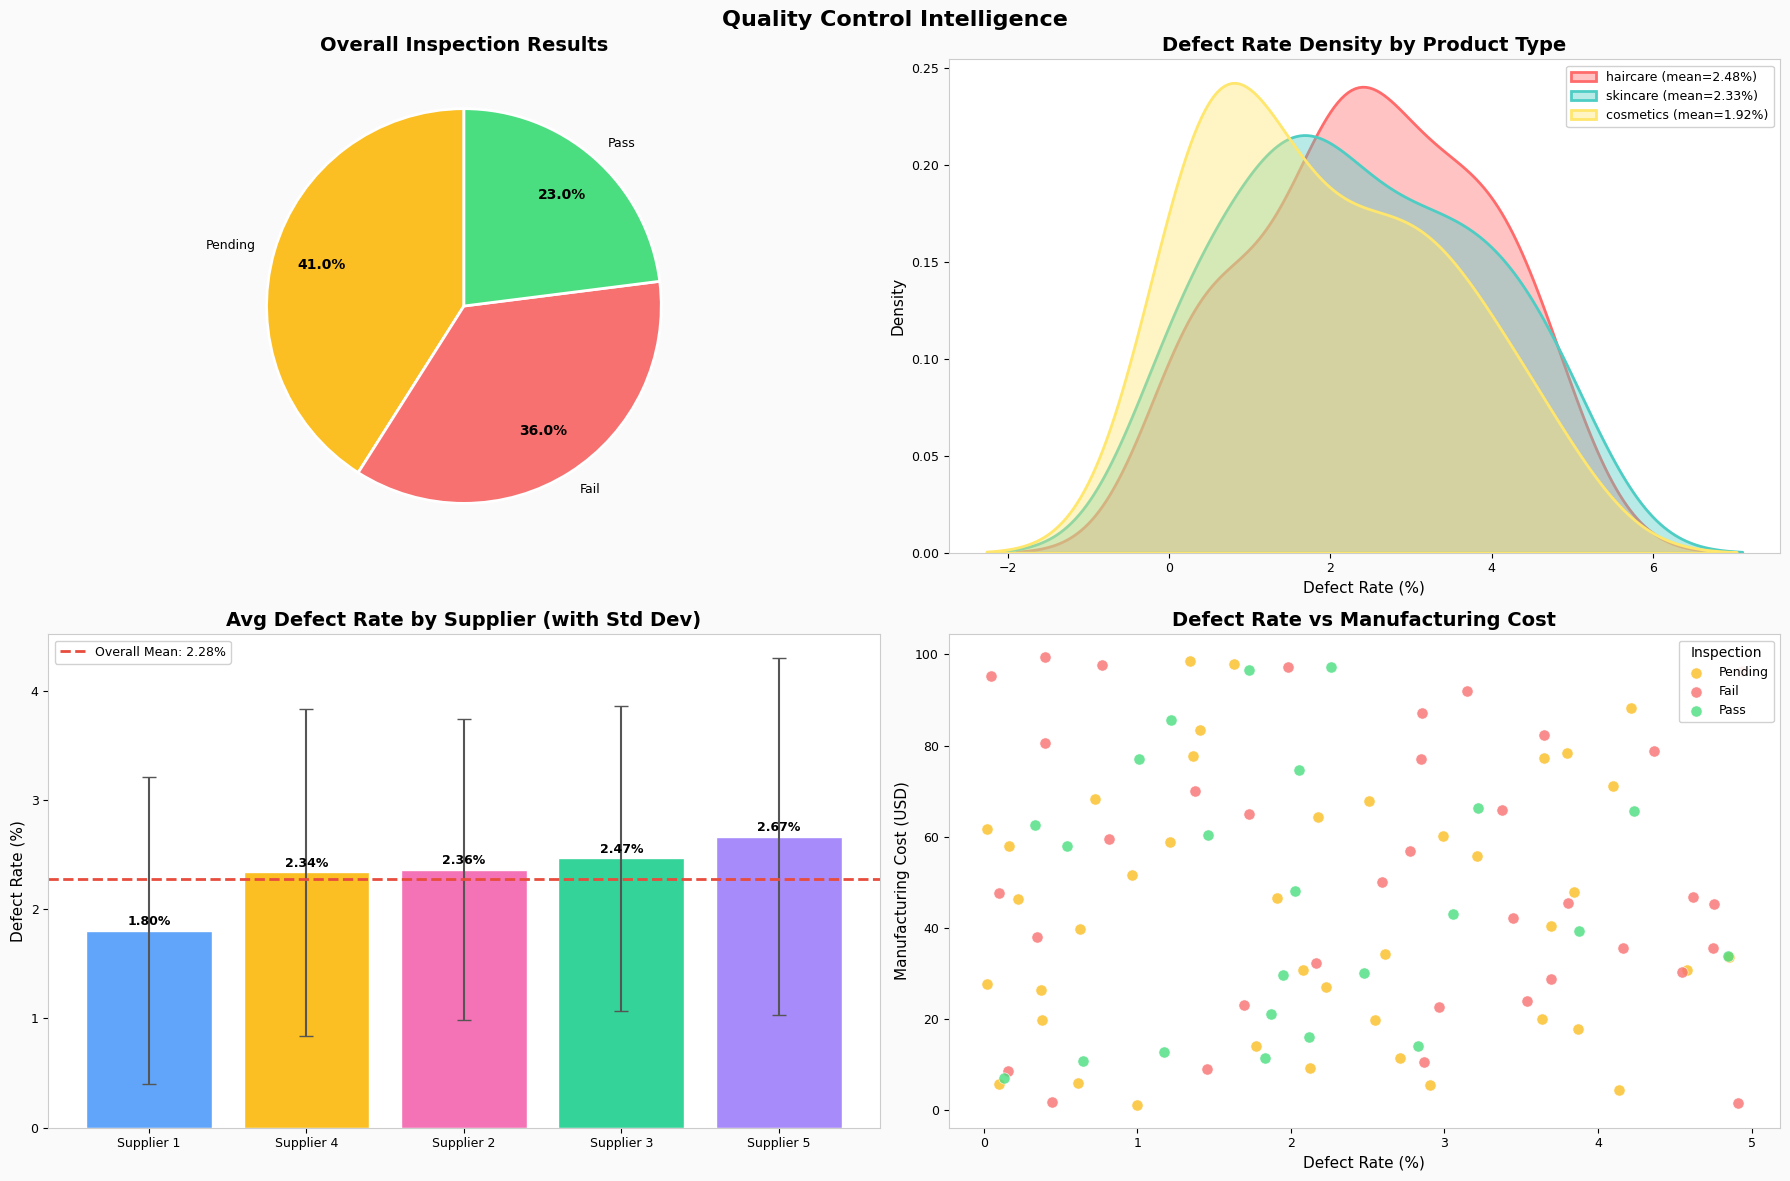

In [46]:
INSPECTION_PALETTE = {'Pass': '#4ADE80', 'Fail': '#F87171', 'Pending': '#FBBF24'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Quality Control Intelligence', fontsize=16, fontweight='bold')

# 1. Inspection results overall
ax = axes[0, 0]
ir_counts = df['Inspection results'].value_counts()
wedges, texts, autotexts = ax.pie(
    ir_counts.values, labels=ir_counts.index,
    colors=[INSPECTION_PALETTE[k] for k in ir_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Overall Inspection Results')

# 2. Defect Rate by Product Type
ax = axes[0, 1]
for ptype in df['Product type'].unique():
    sub = df[df['Product type']==ptype]['Defect rates']
    sns.kdeplot(sub, ax=ax, color=PRODUCT_PALETTE[ptype], fill=True,
                alpha=0.4, label=f'{ptype} (mean={sub.mean():.2f}%)', linewidth=2)
ax.set_title('Defect Rate Density by Product Type')
ax.set_xlabel('Defect Rate (%)')
ax.set_ylabel('Density')
ax.legend()

# 3. Defect rate by Supplier
ax = axes[1, 0]
supp_defect = df.groupby('Supplier name')['Defect rates'].agg(['mean', 'std']).sort_values('mean')
bar_c = [SUPPLIER_PALETTE[s] for s in supp_defect.index]
bars = ax.bar(supp_defect.index, supp_defect['mean'],
              yerr=supp_defect['std'], capsize=5,
              color=bar_c, edgecolor='white',
              error_kw={'ecolor': '#555', 'linewidth': 1.5})
ax.axhline(df['Defect rates'].mean(), color='#E74C3C', linestyle='--', linewidth=2,
           label=f'Overall Mean: {df["Defect rates"].mean():.2f}%')
for bar, val in zip(bars, supp_defect['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Avg Defect Rate by Supplier (with Std Dev)')
ax.set_ylabel('Defect Rate (%)')
ax.legend()

# 4. Defect Rate vs Manufacturing Cost (coloured by inspection)
ax = axes[1, 1]
for status in df['Inspection results'].unique():
    sub = df[df['Inspection results']==status]
    ax.scatter(sub['Defect rates'], sub['Manufacturing costs'],
               color=INSPECTION_PALETTE[status], s=65, alpha=0.8,
               edgecolors='white', linewidth=0.5, label=status)
ax.set_title('Defect Rate vs Manufacturing Cost')
ax.set_xlabel('Defect Rate (%)')
ax.set_ylabel('Manufacturing Cost (USD)')
ax.legend(title='Inspection')

plt.tight_layout()
plt.savefig('13_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Financial cost of quality failures
print('FINANCIAL IMPACT OF INSPECTION OUTCOMES')
print('=' * 60)
quality_fin = df.groupby('Inspection results').agg(
    Count        = ('SKU', 'count'),
    Avg_Revenue  = ('Revenue generated', 'mean'),
    Avg_Mfg_Cost = ('Manufacturing costs', 'mean'),
    Avg_Defects  = ('Defect rates', 'mean'),
    Avg_Profit_M = ('Profit Margin Proxy', 'mean')
).round(2)
print(quality_fin.to_string())

fail_rev  = df[df['Inspection results']=='Fail']['Revenue generated'].mean()
pass_rev  = df[df['Inspection results']=='Pass']['Revenue generated'].mean()
rev_delta = pass_rev - fail_rev

print(f'\nRevenue Penalty of Failing Inspection: ${rev_delta:,.0f} per SKU')
print(f'(Pass avg: ${pass_rev:,.0f}  vs  Fail avg: ${fail_rev:,.0f})')

FINANCIAL IMPACT OF INSPECTION OUTCOMES
                    Count  Avg_Revenue  Avg_Mfg_Cost  Avg_Defects  Avg_Profit_M
Inspection results                                                             
Fail                   36      5293.49         52.23         2.57          0.86
Pass                   23      5709.12         46.14         2.04          0.85
Pending                41      6237.31         43.54         2.15          0.87

Revenue Penalty of Failing Inspection: $416 per SKU
(Pass avg: $5,709  vs  Fail avg: $5,293)


11. Customer Demographics Intelligence

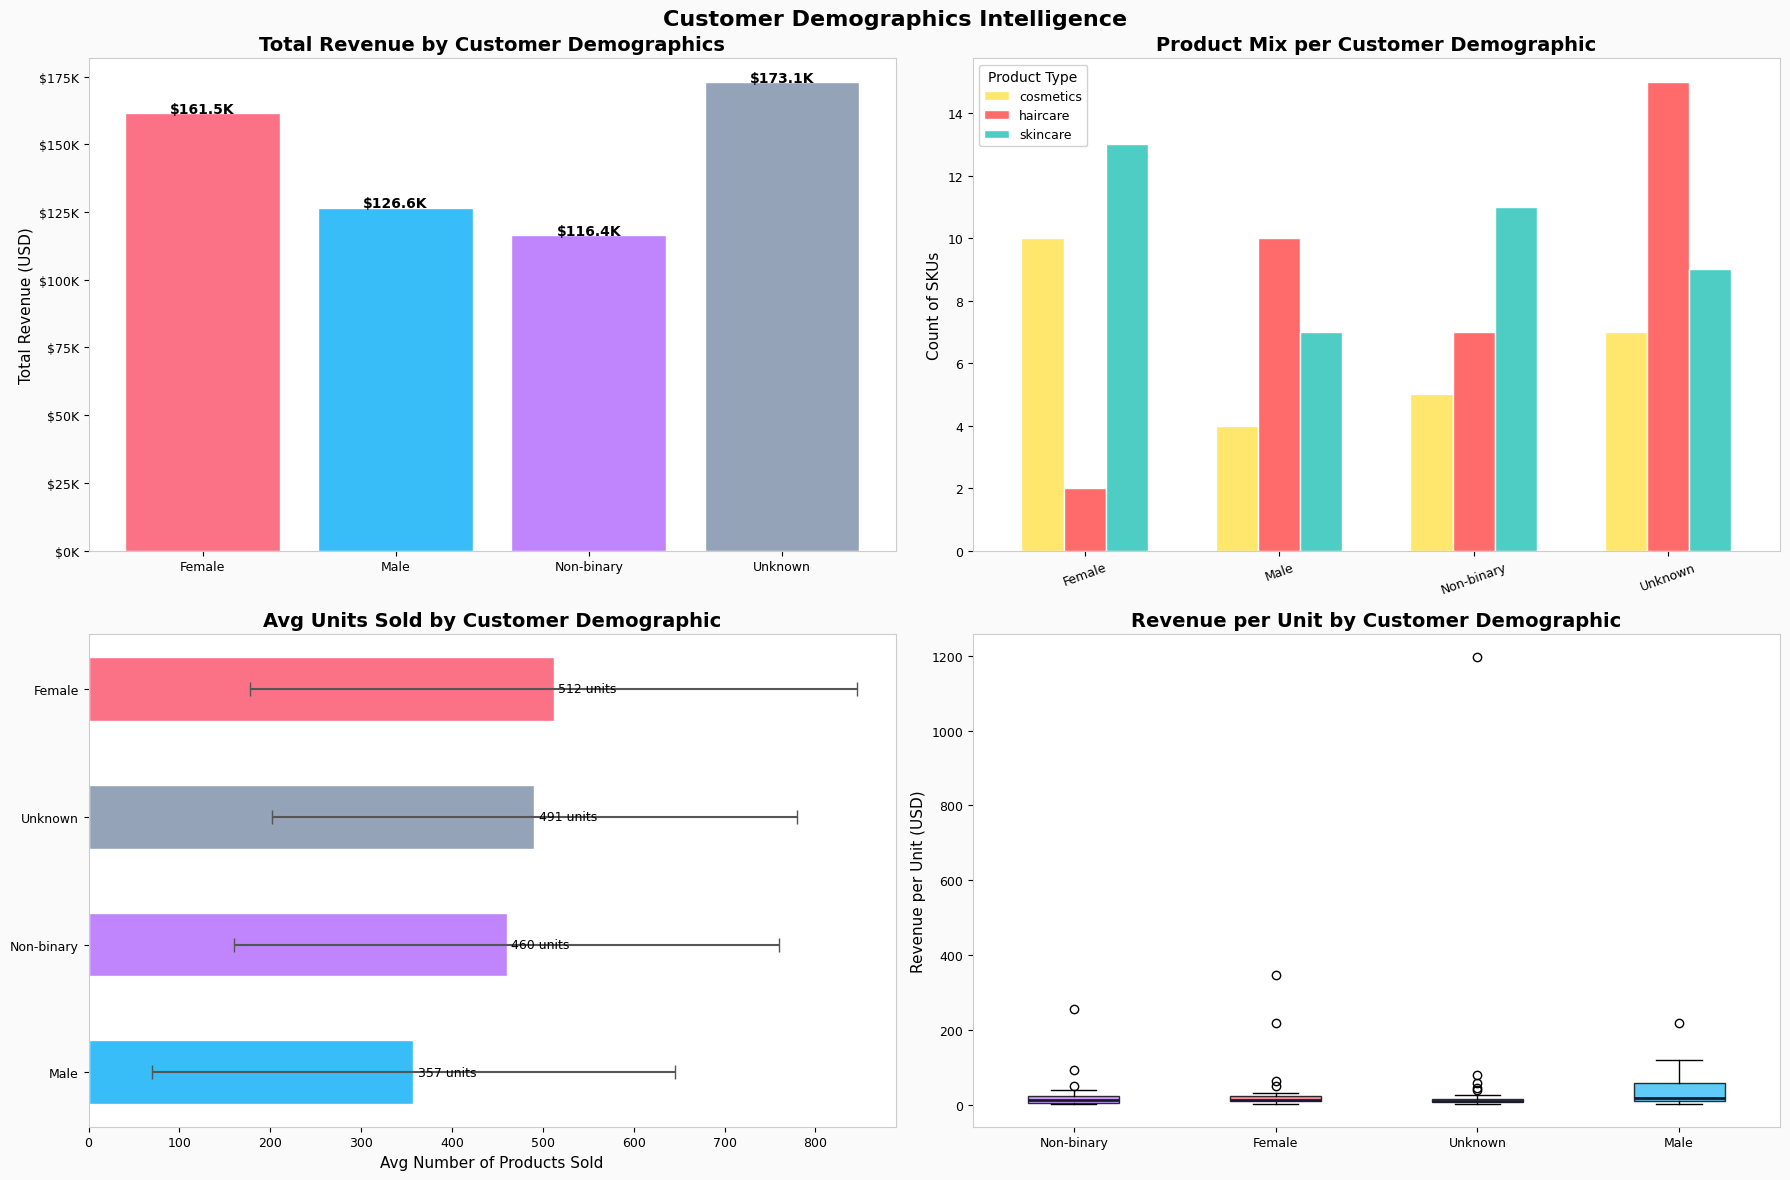

In [48]:
DEMO_PALETTE = {'Non-binary': '#C084FC', 'Female': '#FB7185', 'Male': '#38BDF8', 'Unknown': '#94A3B8'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Customer Demographics Intelligence', fontsize=16, fontweight='bold')

# 1. Revenue by Demographics
ax = axes[0, 0]
demo_rev = df.groupby('Customer demographics')['Revenue generated'].agg(['sum', 'mean'])
bars = ax.bar(demo_rev.index, demo_rev['sum'],
              color=[DEMO_PALETTE[d] for d in demo_rev.index],
              edgecolor='white', linewidth=1)
for bar, val in zip(bars, demo_rev['sum']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${val/1000:.1f}K', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Total Revenue by Customer Demographics')
ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# 2. Product mix per demographic
ax = axes[0, 1]
demo_prod = df.groupby(['Customer demographics', 'Product type']).size().unstack(fill_value=0)
demo_prod.plot(kind='bar', ax=ax,
               color=[PRODUCT_PALETTE[p] for p in demo_prod.columns],
               edgecolor='white', width=0.65)
ax.set_title('Product Mix per Customer Demographic')
ax.set_xlabel('')
ax.set_ylabel('Count of SKUs')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Product Type')

# 3. Avg units sold per demographic
ax = axes[1, 0]
demo_units = df.groupby('Customer demographics')['Number of products sold'].agg(['mean', 'std']).sort_values('mean')
bars = ax.barh(demo_units.index, demo_units['mean'],
               xerr=demo_units['std'], capsize=5,
               color=[DEMO_PALETTE[d] for d in demo_units.index],
               edgecolor='white', height=0.5,
               error_kw={'ecolor': '#555', 'linewidth': 1.5})
for bar, val in zip(bars, demo_units['mean']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} units', va='center', fontsize=9)
ax.set_title('Avg Units Sold by Customer Demographic')
ax.set_xlabel('Avg Number of Products Sold')

# 4. Revenue per unit by demographic
ax = axes[1, 1]
demo_rpu = df.groupby('Customer demographics')['Revenue per Unit'].describe()
bp = ax.boxplot(
    [df[df['Customer demographics']==d]['Revenue per Unit'].dropna().values
     for d in df['Customer demographics'].unique()],
    patch_artist=True,
    medianprops=dict(color='#1A1A2E', linewidth=2)
)
for patch, demo in zip(bp['boxes'], df['Customer demographics'].unique()):
    patch.set_facecolor(DEMO_PALETTE[demo])
    patch.set_alpha(0.8)
ax.set_xticks(range(1, len(df['Customer demographics'].unique())+1))
ax.set_xticklabels(df['Customer demographics'].unique())
ax.set_title('Revenue per Unit by Customer Demographic')
ax.set_ylabel('Revenue per Unit (USD)')

plt.tight_layout()
plt.savefig('14_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

12. Cost Efficiency Analysis

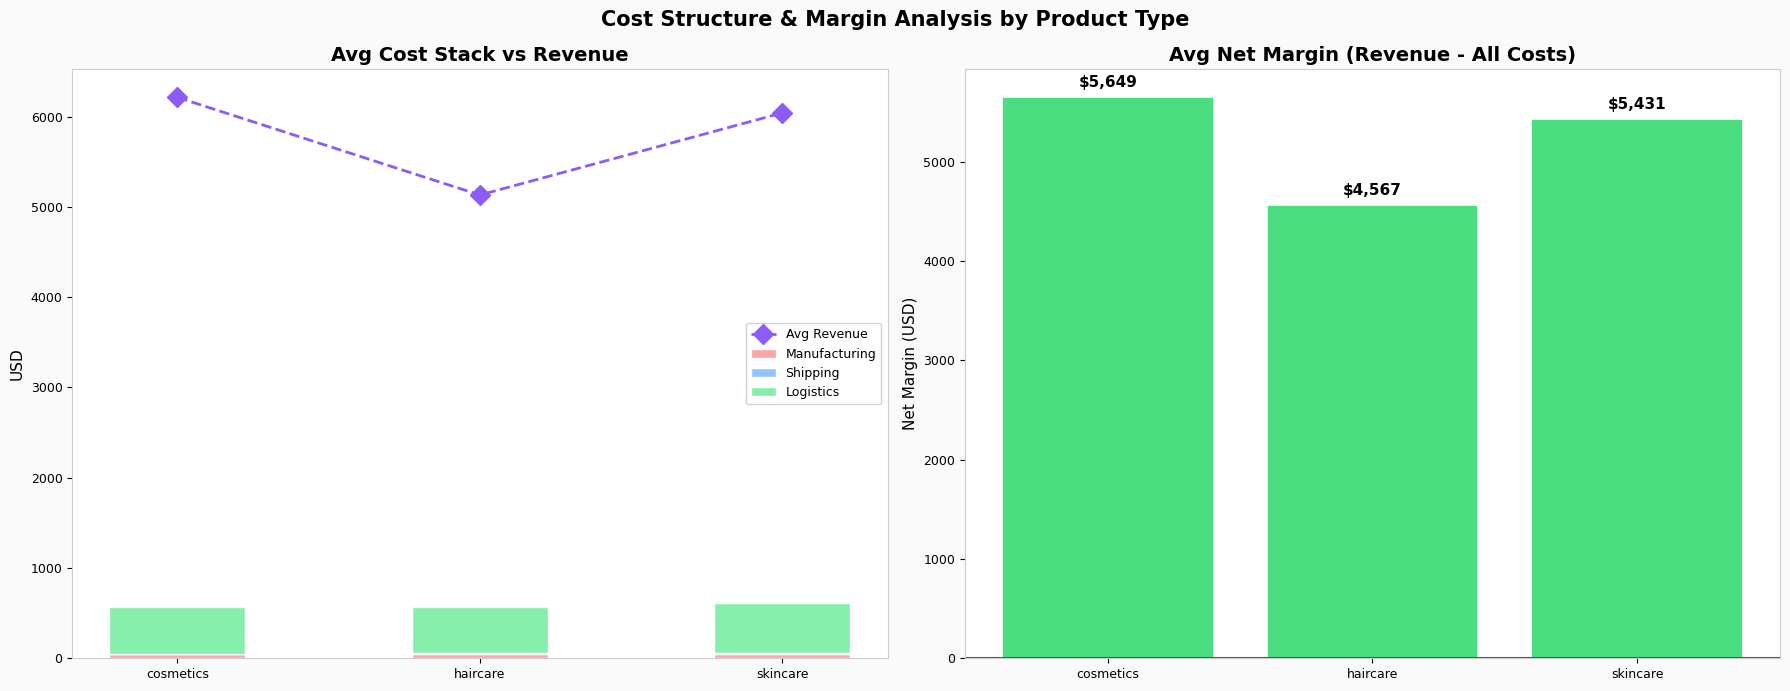

In [49]:
# Average cost breakdown per product type
cost_breakdown = df.groupby('Product type').agg(
    Manufacturing_Cost = ('Manufacturing costs', 'mean'),
    Shipping_Cost      = ('Shipping costs', 'mean'),
    Logistics_Cost     = ('Costs', 'mean'),
    Revenue            = ('Revenue generated', 'mean')
).reset_index()
cost_breakdown['Total_Cost'] = (cost_breakdown['Manufacturing_Cost'] +
                                 cost_breakdown['Shipping_Cost'] +
                                 cost_breakdown['Logistics_Cost'])
cost_breakdown['Net_Margin']  = cost_breakdown['Revenue'] - cost_breakdown['Total_Cost']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Cost Structure & Margin Analysis by Product Type', fontsize=15, fontweight='bold')

# Stacked Bar: Cost breakdown
ax = axes[0]
x = np.arange(len(cost_breakdown))
w = 0.45
b1 = ax.bar(x, cost_breakdown['Manufacturing_Cost'], width=w, label='Manufacturing', color='#FCA5A5', edgecolor='white')
b2 = ax.bar(x, cost_breakdown['Shipping_Cost'], width=w, bottom=cost_breakdown['Manufacturing_Cost'],
            label='Shipping', color='#93C5FD', edgecolor='white')
b3 = ax.bar(x, cost_breakdown['Logistics_Cost'],
            width=w, bottom=cost_breakdown['Manufacturing_Cost']+cost_breakdown['Shipping_Cost'],
            label='Logistics', color='#86EFAC', edgecolor='white')
ax.plot(x, cost_breakdown['Revenue'], 'D--', color='#8B5CF6', markersize=10, linewidth=2,
        label='Avg Revenue')
ax.set_xticks(x)
ax.set_xticklabels(cost_breakdown['Product type'])
ax.set_title('Avg Cost Stack vs Revenue')
ax.set_ylabel('USD')
ax.legend()

# Net Margin
ax = axes[1]
margin_colors = ['#4ADE80' if m > 0 else '#F87171' for m in cost_breakdown['Net_Margin']]
bars = ax.bar(cost_breakdown['Product type'], cost_breakdown['Net_Margin'],
              color=margin_colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, cost_breakdown['Net_Margin']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (100 if val > 0 else -150),
            f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(0, color='#475569', linewidth=1.5)
ax.set_title('Avg Net Margin (Revenue - All Costs)')
ax.set_ylabel('Net Margin (USD)')

plt.tight_layout()
plt.savefig('15_cost_structure.png', dpi=150, bbox_inches='tight')
plt.show()

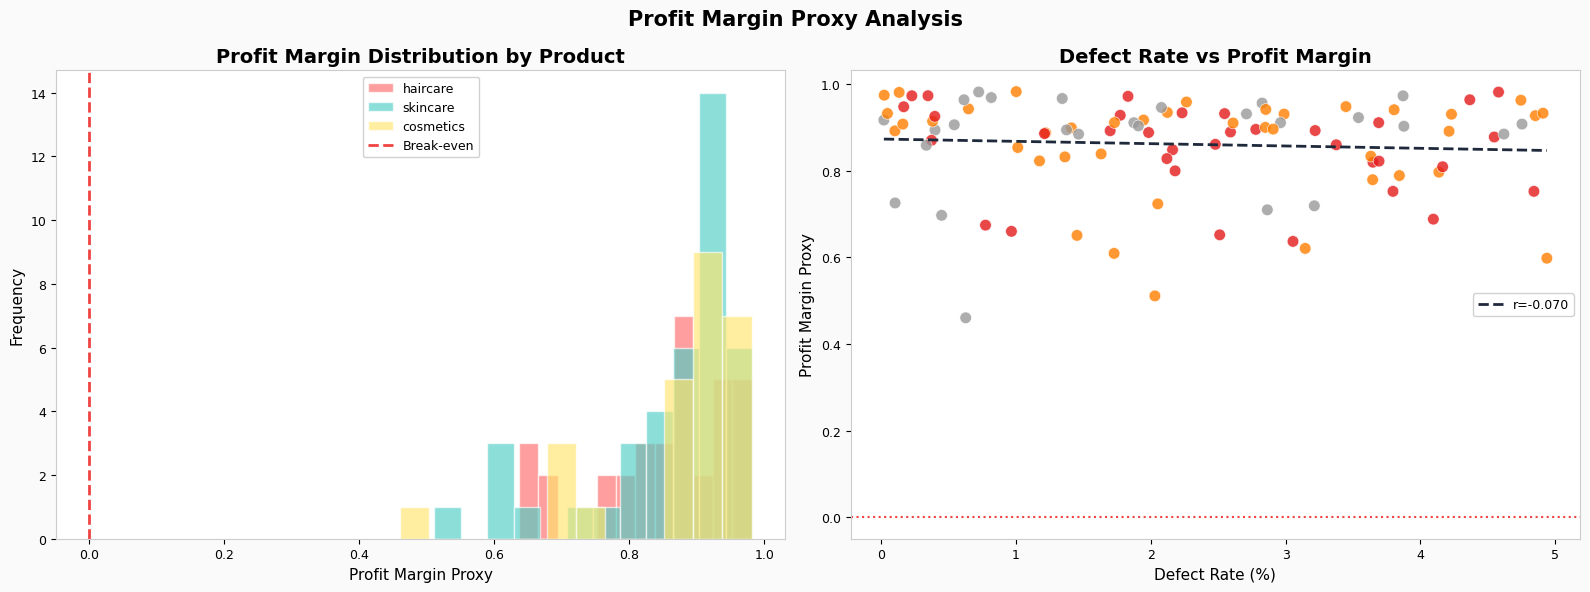

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Profit Margin Proxy Analysis', fontsize=15, fontweight='bold')

# Distribution of profit margin by product
ax = axes[0]
for ptype in df['Product type'].unique():
    sub = df[df['Product type']==ptype]['Profit Margin Proxy'].dropna()
    ax.hist(sub, bins=12, alpha=0.65, color=PRODUCT_PALETTE[ptype], label=ptype, edgecolor='white')
ax.axvline(0, color='#EF4444', linewidth=2, linestyle='--', label='Break-even')
ax.set_title('Profit Margin Distribution by Product')
ax.set_xlabel('Profit Margin Proxy')
ax.set_ylabel('Frequency')
ax.legend()

# Profit margin vs Defect Rate
ax = axes[1]
sc = ax.scatter(df['Defect rates'], df['Profit Margin Proxy'],
                c=[{'haircare': 0, 'skincare': 1, 'cosmetics': 2}[p] for p in df['Product type']],
                cmap='Set1', s=70, alpha=0.8, edgecolors='white', linewidth=0.5)
m, b, r, p_val, _ = stats.linregress(df['Defect rates'], df['Profit Margin Proxy'].fillna(df['Profit Margin Proxy'].median()))
x_line = np.linspace(df['Defect rates'].min(), df['Defect rates'].max(), 100)
ax.plot(x_line, m*x_line+b, color='#1E293B', linewidth=2, linestyle='--',
        label=f'r={r:.3f}')
ax.axhline(0, color='#EF4444', linewidth=1.5, linestyle=':')
ax.set_title('Defect Rate vs Profit Margin')
ax.set_xlabel('Defect Rate (%)')
ax.set_ylabel('Profit Margin Proxy')
ax.legend()

plt.tight_layout()
plt.savefig('16_margin.png', dpi=150, bbox_inches='tight')
plt.show()

13. Advanced Multi-Dimensional Insights

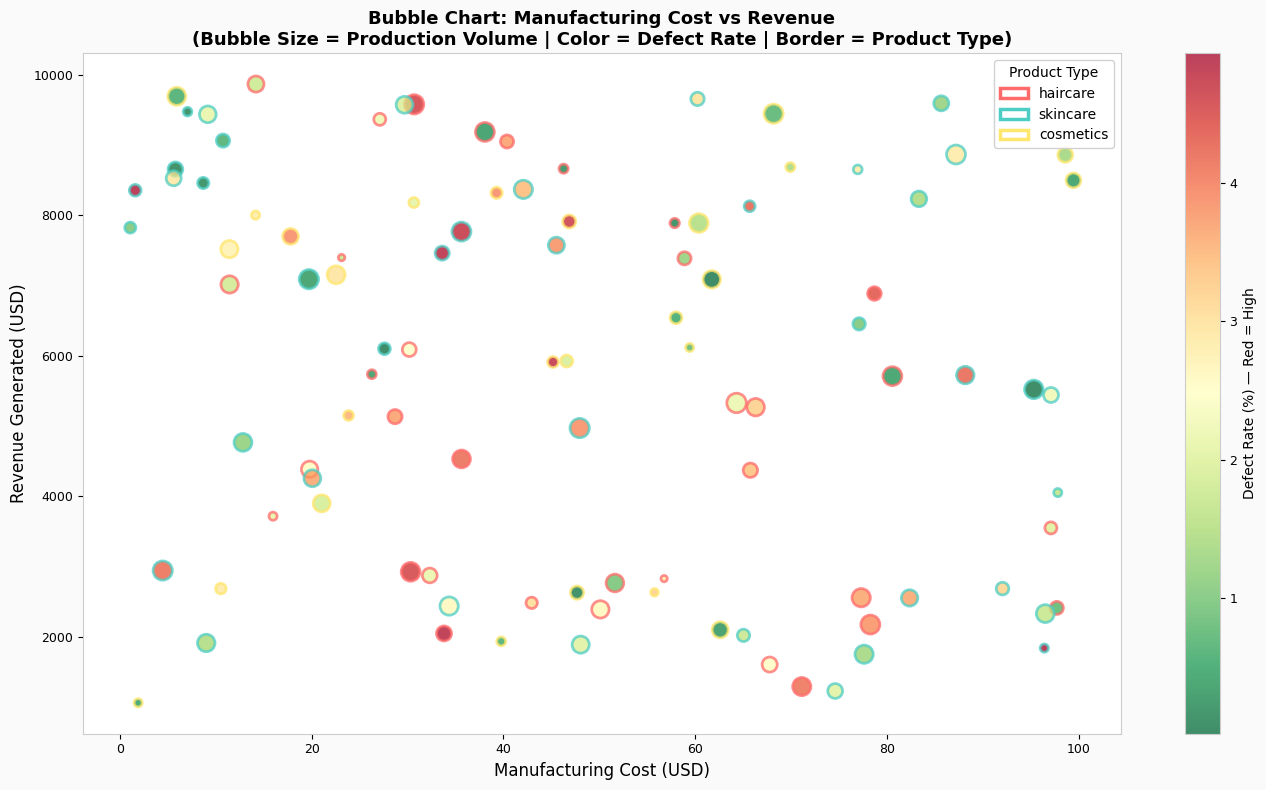

In [51]:
fig, ax = plt.subplots(figsize=(14, 8))

for ptype in df['Product type'].unique():
    sub = df[df['Product type']==ptype]
    scatter = ax.scatter(
        sub['Manufacturing costs'],
        sub['Revenue generated'],
        s=sub['Production volumes'] / 5,
        c=sub['Defect rates'],
        cmap='RdYlGn_r',
        alpha=0.75,
        edgecolors=PRODUCT_PALETTE[ptype],
        linewidth=2,
        label=ptype,
        vmin=df['Defect rates'].min(),
        vmax=df['Defect rates'].max()
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Defect Rate (%) — Red = High', fontsize=10)

ax.set_xlabel('Manufacturing Cost (USD)', fontsize=12)
ax.set_ylabel('Revenue Generated (USD)', fontsize=12)
ax.set_title(
    'Bubble Chart: Manufacturing Cost vs Revenue\n'
    '(Bubble Size = Production Volume | Color = Defect Rate | Border = Product Type)',
    fontsize=13, fontweight='bold'
)
legend_patches = [mpatches.Patch(edgecolor=c, facecolor='none', linewidth=2.5, label=k)
                  for k, c in PRODUCT_PALETTE.items()]
ax.legend(handles=legend_patches, title='Product Type', fontsize=10)

plt.tight_layout()
plt.savefig('17_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

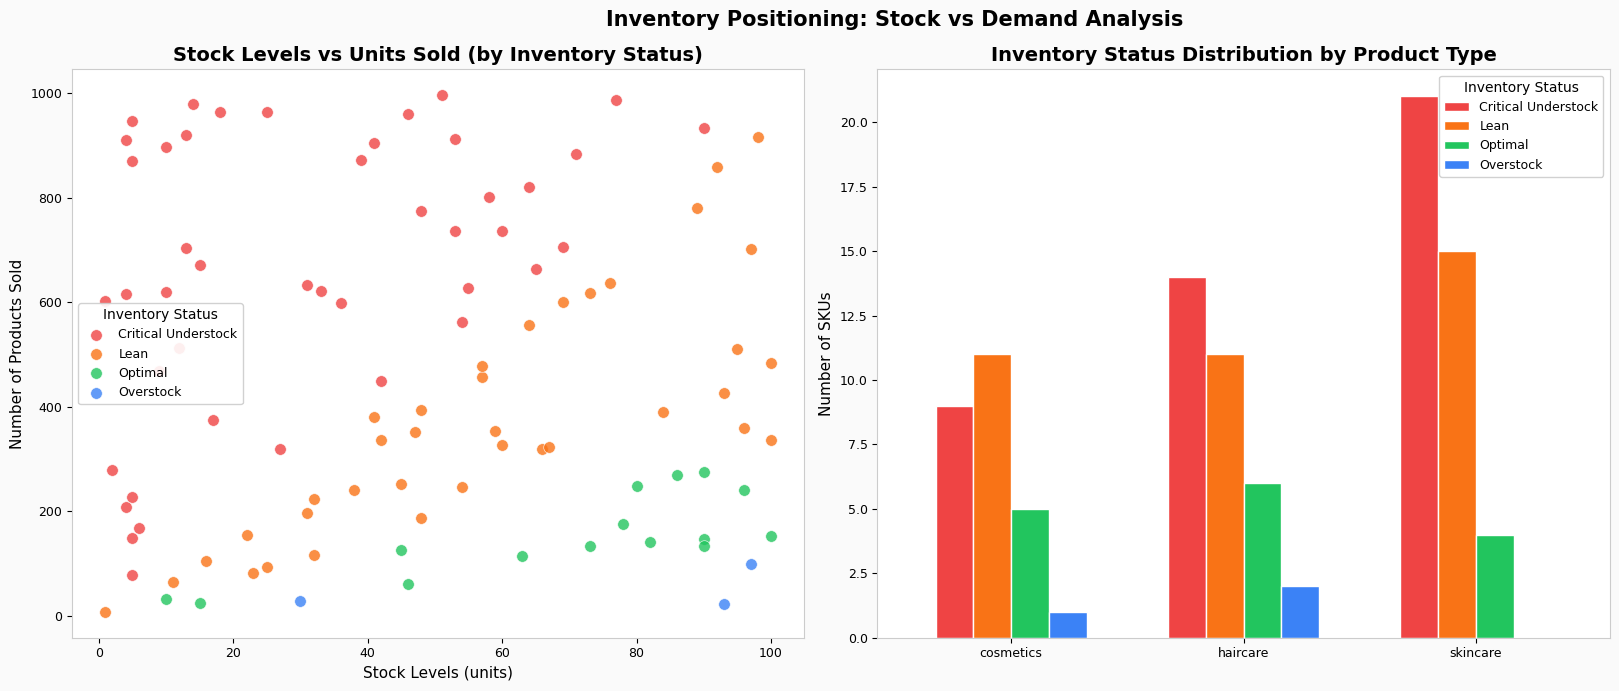


SKU Count by Inventory Status:
Stock Status
Critical Understock    44
Lean                   37
Optimal                15
Overstock               3


In [52]:
# Stock vs Sales: Identify overstock, understock, optimal SKUs
df['Stock Status'] = pd.cut(
    df['Stock-to-Sales Ratio'],
    bins=[0, 0.1, 0.3, 0.8, float('inf')],
    labels=['Critical Understock', 'Lean', 'Optimal', 'Overstock']
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Inventory Positioning: Stock vs Demand Analysis', fontsize=15, fontweight='bold')

# Scatter: Stock levels vs Sales
ax = axes[0]
stock_palette = {'Critical Understock': '#EF4444', 'Lean': '#F97316',
                 'Optimal': '#22C55E', 'Overstock': '#3B82F6'}

for status in df['Stock Status'].dropna().unique():
    sub = df[df['Stock Status']==status]
    ax.scatter(sub['Stock levels'], sub['Number of products sold'],
               color=stock_palette[status], s=70, alpha=0.8,
               edgecolors='white', linewidth=0.5, label=status)
ax.set_xlabel('Stock Levels (units)')
ax.set_ylabel('Number of Products Sold')
ax.set_title('Stock Levels vs Units Sold (by Inventory Status)')
ax.legend(title='Inventory Status')

# SKU count per stock status per product
ax = axes[1]
ss_prod = df.groupby(['Product type', 'Stock Status']).size().unstack(fill_value=0)
colors_status = [stock_palette[c] for c in ss_prod.columns]
ss_prod.plot(kind='bar', ax=ax, color=colors_status, edgecolor='white', width=0.65)
ax.set_title('Inventory Status Distribution by Product Type')
ax.set_xlabel('')
ax.set_ylabel('Number of SKUs')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Inventory Status', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('18_inventory.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSKU Count by Inventory Status:')
print(df['Stock Status'].value_counts().to_string())

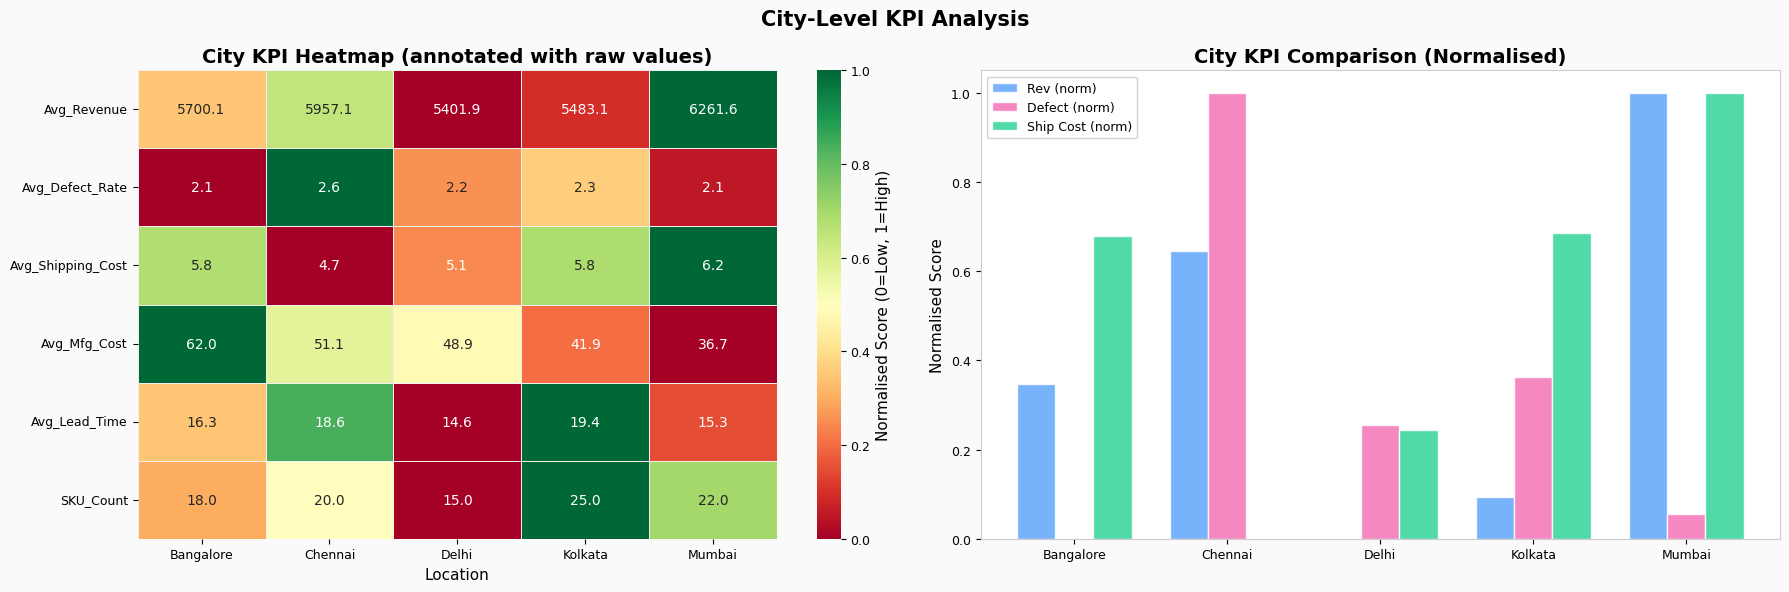

In [53]:
# City-level heatmap: multiple KPIs
loc_agg = df.groupby('Location').agg(
    Avg_Revenue       = ('Revenue generated', 'mean'),
    Avg_Defect_Rate   = ('Defect rates', 'mean'),
    Avg_Shipping_Cost = ('Shipping costs', 'mean'),
    Avg_Mfg_Cost      = ('Manufacturing costs', 'mean'),
    Avg_Lead_Time     = ('Lead time', 'mean'),
    SKU_Count         = ('SKU', 'count')
).round(2)

# Normalise for heatmap
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
try:
    loc_norm = pd.DataFrame(
        scaler.fit_transform(loc_agg),
        columns=loc_agg.columns,
        index=loc_agg.index
    )
except ImportError:
    loc_norm = (loc_agg - loc_agg.min()) / (loc_agg.max() - loc_agg.min())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('City-Level KPI Analysis', fontsize=15, fontweight='bold')

sns.heatmap(loc_norm.T, cmap='RdYlGn', annot=loc_agg.T, fmt='.1f',
            linewidths=0.5, linecolor='#F0F0F0', ax=axes[0],
            cbar_kws={'label': 'Normalised Score (0=Low, 1=High)'})
axes[0].set_title('City KPI Heatmap (annotated with raw values)')
axes[0].tick_params(axis='x', rotation=0)

# Spider/Radar not in matplotlib base — use grouped bar instead
ax = axes[1]
bar_data = loc_agg[['Avg_Revenue', 'Avg_Defect_Rate', 'Avg_Shipping_Cost']].copy()
bar_norm = (bar_data - bar_data.min()) / (bar_data.max() - bar_data.min())
x = np.arange(len(bar_norm))
w = 0.25
metrics_labels = ['Rev (norm)', 'Defect (norm)', 'Ship Cost (norm)']
metric_colors = ['#60A5FA', '#F472B6', '#34D399']
for i, (col, label, color) in enumerate(zip(bar_norm.columns, metrics_labels, metric_colors)):
    ax.bar(x + i*w, bar_norm[col], width=w, label=label,
           color=color, edgecolor='white', alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(bar_norm.index, rotation=0)
ax.set_title('City KPI Comparison (Normalised)')
ax.set_ylabel('Normalised Score')
ax.legend()

plt.tight_layout()
plt.savefig('19_city_kpi.png', dpi=150, bbox_inches='tight')
plt.show()